In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Cargamos los datos crudos desde la carpeta data/raw
df = pd.read_csv('../../data/raw/nhanes_ui_women.csv')

# Mostramos las primeras 5 filas para comprobar que cargó bien
df.head()

,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


In [8]:
# Ver cuántas filas y columnas tiene el dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# Ver información general de las columnas (tipos de datos y valores no nulos)
df.info()


El dataset tiene 9074 filas y 27 columnas.

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_participante            9074 non-null   float64
 1   ciclo_nhanes               9074 non-null   str    
 2   peso_encuesta              4321 non-null   float64
 3   edad_anios                 9074 non-null   float64
 4   etnia                      9074 non-null   float64
 5   pais_nacimiento            9067 non-null   float64
 6   imc                        7620 non-null   float64
 7   dx_hipertension            9074 non-null   float64
 8   medicacion_hta_cicloP      1694 non-null   float64
 9   medicacion_hta_cicloL      1599 non-null   float64
 10  dx_diabetes                9074 non-null   float64
 11  dx_cancer                  9074 non-null   float64
 12  dx_artritis                9074 non-null   float64
 13  fumadora_alguna

In [9]:
# 1. Veamos cuántos duplicados totales hay
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas en el dataset: {duplicados}\n")

# 2. Veamos cuántos valores nulos (faltantes) hay por columna
print("Valores nulos por columna:")
nulos = df.isnull().sum()

# Filtra y muestra solo las columnas que SI tienen nulos, ordenadas de mayor a menor
columnas_con_nulos = nulos[nulos > 0].sort_values(ascending=False)
print(columnas_con_nulos)


Número de filas duplicadas en el dataset: 0

Valores nulos por columna:
ui_urgencia_frecuencia       7724
medicacion_hta_cicloL        7475
medicacion_hta_cicloP        7380
ui_esfuerzo_frecuencia       7339
ui_molestia_percibida        6706
ui_cantidad                  5522
ui_otro_tipo_presente        5020
ui_impacto_actividades       4861
peso_encuesta                4753
actividad_fisica_vigorosa    4321
ui_urgencia_presente         2190
ui_esfuerzo_presente         2185
ui_frecuencia                2180
imc                          1454
nivel_pobreza_familiar        905
pais_nacimiento                 7
fumadora_alguna_vez             6
dtype: int64


/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/428606414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


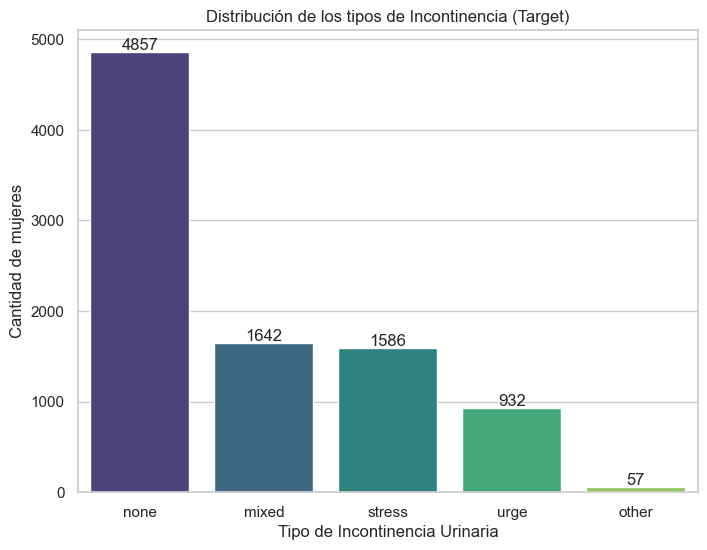


Porcentaje de cada clase en el target:
target_tipo_ui
none      53.53
mixed     18.10
stress    17.48
urge      10.27
other      0.63
Name: proportion, dtype: float64


In [10]:
# Gráfico de barras para ver la distribución de la variable objetivo (target)
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df, 
    x='target_tipo_ui', 
    order=df['target_tipo_ui'].value_counts().index,
    palette='viridis' # Le damos un poco de color
)

# Añadimos titulo y etiquetas a los ejes
plt.title('Distribución de los tipos de Incontinencia (Target)')
plt.xlabel('Tipo de Incontinencia Urinaria')
plt.ylabel('Cantidad de mujeres')

# Esto añade el numerito exacto encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show() # Mostrar el gráfico

# También los imprimimos como porcentajes para tener el dato exacto
print("\nPorcentaje de cada clase en el target:")
print(round(df['target_tipo_ui'].value_counts(normalize=True) * 100, 2))


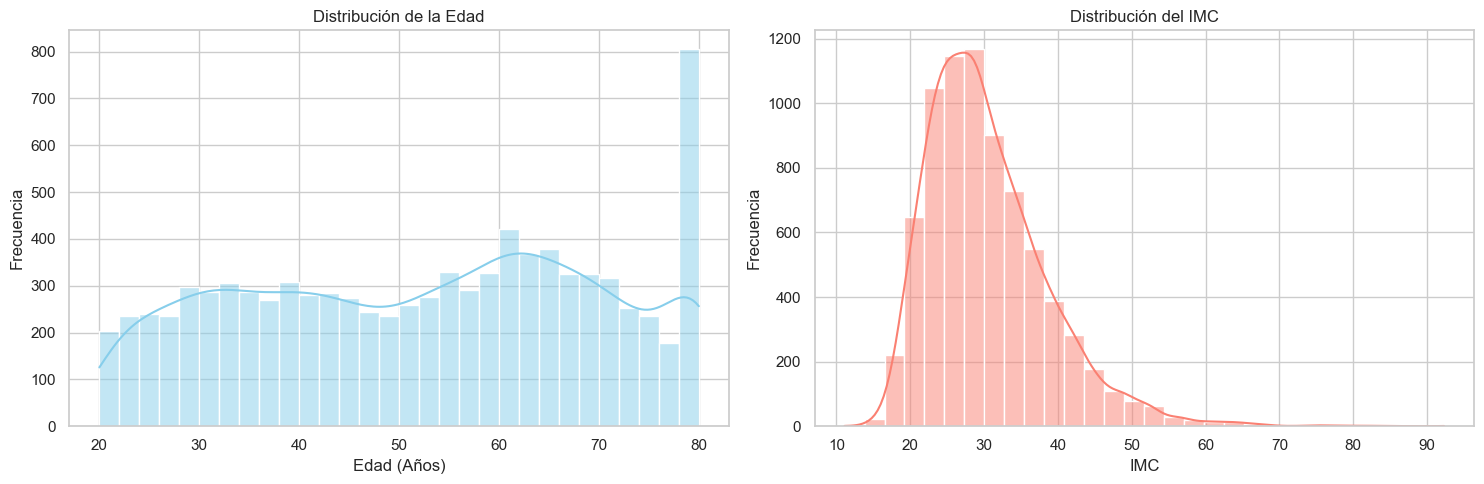


Estadísticas descriptivas básicas para Edad e IMC:


,edad_anios,imc
count,9074.000000,7620.000000
mean,52.077584,30.471325
std,17.627592,8.212430
min,20.000000,11.100000
25%,37.000000,24.600000
50%,54.000000,29.000000
75%,67.000000,34.800000
max,80.000000,92.300000


In [11]:
# Hacemos un lienzo con dos subgráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Histograma de la Edad
sns.histplot(data=df, x='edad_anios', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Edad')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Histograma del IMC
sns.histplot(data=df, x='imc', bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución del IMC')
axes[1].set_xlabel('IMC')
axes[1].set_ylabel('Frecuencia')

# Mostramos ambos gráficos juntos
plt.tight_layout()
plt.show()

# También imprimimos un pequeño resumen estadístico (media, medias, minimo, máximo) de ellas
print("\nEstadísticas descriptivas básicas para Edad e IMC:")
df[['edad_anios', 'imc']].describe()


/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/80007346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_tipo_ui', y='edad_anios', ax=axes[0], palette='Set2')
/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/80007346.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_tipo_ui', y='imc', ax=axes[1], palette='Set2')


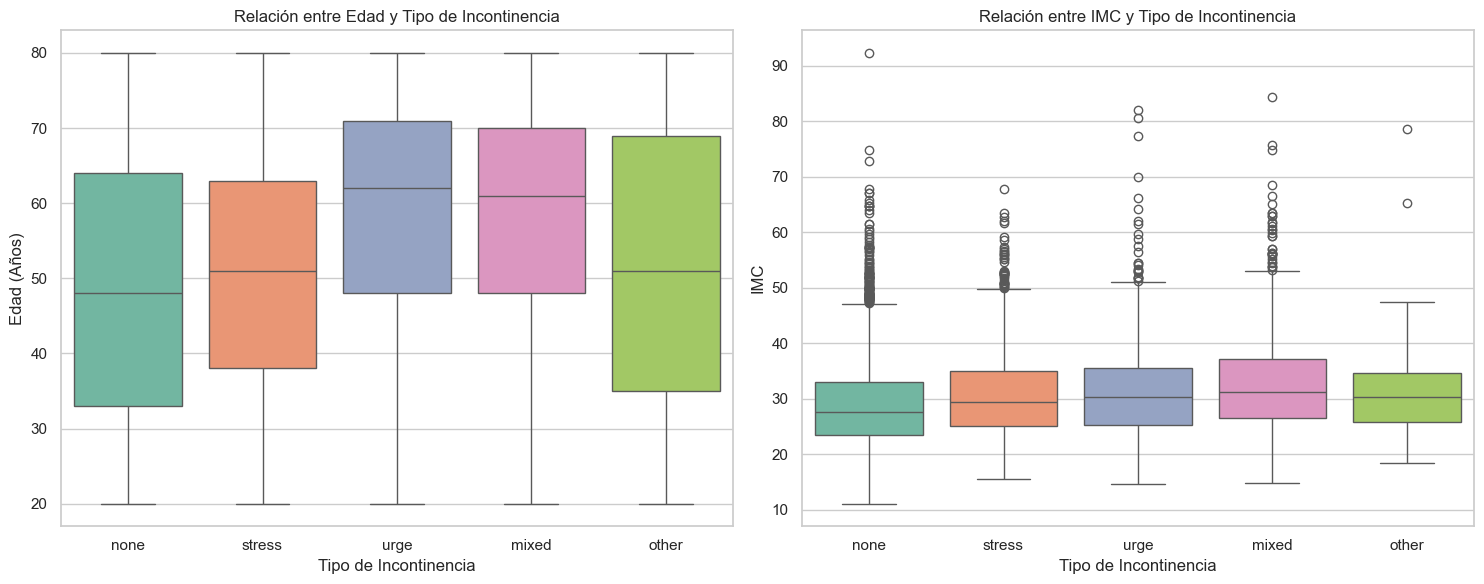

In [12]:
# Hacemos un lienzo con dos subgráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Edad vs Tipo de Incontinencia (Boxplot)
sns.boxplot(data=df, x='target_tipo_ui', y='edad_anios', ax=axes[0], palette='Set2')
axes[0].set_title('Relación entre Edad y Tipo de Incontinencia')
axes[0].set_xlabel('Tipo de Incontinencia')
axes[0].set_ylabel('Edad (Años)')

# Gráfico 2: IMC vs Tipo de Incontinencia (Boxplot)
sns.boxplot(data=df, x='target_tipo_ui', y='imc', ax=axes[1], palette='Set2')
axes[1].set_title('Relación entre IMC y Tipo de Incontinencia')
axes[1].set_xlabel('Tipo de Incontinencia')
axes[1].set_ylabel('IMC')

# Ajustamos para que no se superpongan y mostramos
plt.tight_layout()
plt.show()


### 📝 Conclusiones Finales del EDA

1. **Estructura y Calidad de Datos:** El dataset contiene más de 9000 registros. Hay una cantidad significativa de valores nulos en las columnas específicas de incontinencia (`ui_frecuencia`, `ui_cantidad`, etc.), lo cual es esperado dado que las pacientes sin incontinencia (`none`) no responden esas preguntas de seguimiento.
2. **Variable Objetivo (`target_tipo_ui`):** Existe un desbalanceo de clases importante, siendo la clase "sana" (`none`) la mayoritaria, seguida de `stress` y `mixed`. Esto es crucial tenerlo en cuenta para la fase de modelado (quizá necesitemos técnicas de balanceo).
3. **Relación Edad/Target:** Se observa una clara tendencia a mayor edad en tipos de incontinencia como la de urgencia (`urge`) o mixta (`mixed`) comparado con mujeres sin incontinencia (`none`) o por esfuerzo (`stress`).
4. **Relación IMC/Target:** Hay una presencia notable de valores atípicos (outliers) en los rangos superiores de IMC en todas las categorías. En general, la mediana del IMC de las mujeres con algún tipo de incontinencia tiende a ser ligeramente superior a la de las mujeres sin incontinencia.
